In [1]:
%reload_ext autoreload
%autoreload 2
import mujoco
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

sim = MiniprojectSimulation(level=4, seed=777)
controller = Controller(sim)

thorax_id = mujoco.mj_name2id(sim.mj_model, mujoco.mjtObj.mjOBJ_BODY, f"{sim.fly.name}/c_thorax")

vision_signal = []
olfactory_signal = []
wind_signal = []
wind_direction = []
wind_direction_estimated = []
fly_thorax_quat = []
for _ in trange(20000): #10000
    joint_angles, adhesion = controller.step(sim)
    vision_signal.append(controller.vision.current_signal)
    olfactory_signal.append(controller.olfaction.current_signal)
    wind_signal.append(controller.wind.current_signal)
    wind_direction.append(sim.mj_model.opt.wind[:2].copy())
    wind_direction_estimated.append(controller.wind.current_estimated_wind_angle)
    fly_thorax_quat.append(sim.mj_data.xquat[thorax_id].copy())  # [w, x, y, z]
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

sim.renderer.show_in_notebook()

Failed to read module file 'C:\Users\Xgili\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Xgili\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", l

nmf/backcam This browser does not support the video tag.


birdeyecam This browser does not support the video tag.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

vision_signal = np.asarray(vision_signal)
olfactory_signal = np.asarray(olfactory_signal)
wind_signal = np.asarray(wind_signal)
wind_direction = np.asarray(wind_direction)        # shape (T, 2): [wind_x, wind_y] in world frame
wind_direction_estimated = np.degrees(np.asarray(wind_direction_estimated))  # shape (T,): estimated wind angle in fly's egocentric frame
fly_thorax_quat = np.asarray(fly_thorax_quat)      # shape (T, 4): [w, x, y, z]

x = np.arange(len(vision_signal))

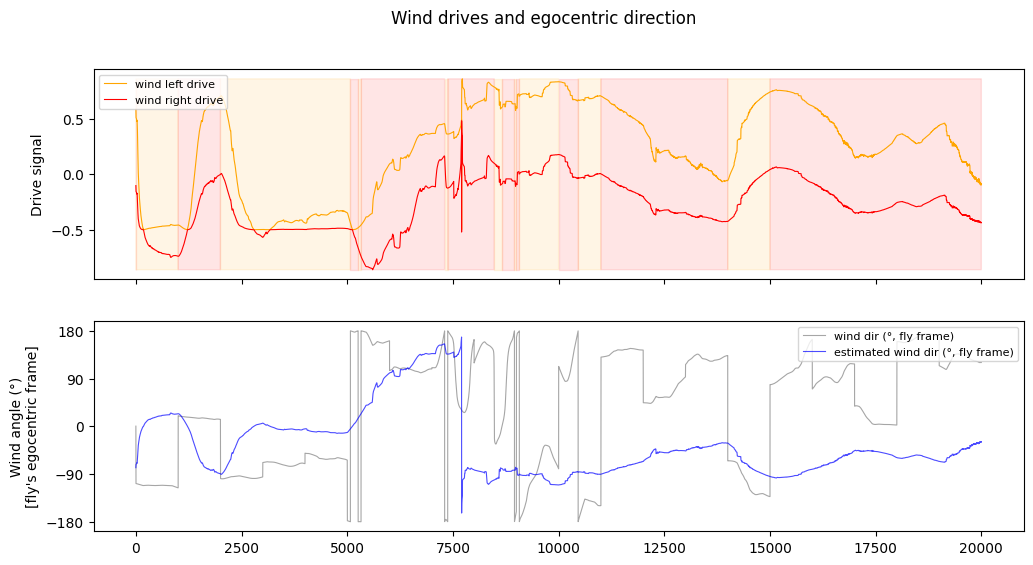

In [3]:
from matplotlib.gridspec import GridSpec

# World-frame wind angle and magnitude from MuJoCo opt.wind
wind_angle_world = np.arctan2(wind_direction[:, 1], wind_direction[:, 0])
wind_magnitude   = np.linalg.norm(wind_direction, axis=1)

# Fly heading (yaw) extracted from thorax quaternion [w, x, y, z]
w, x_, y_, z_ = fly_thorax_quat[:, 0], fly_thorax_quat[:, 1], fly_thorax_quat[:, 2], fly_thorax_quat[:, 3]
fly_yaw = np.arctan2(2 * (w * z_ + x_ * y_), 1 - 2 * (y_**2 + z_**2))

# Wind angle in fly's egocentric frame (wrapped to [-180, 180])
egocentric_wind_angle = np.degrees(np.arctan2(
    np.sin(wind_angle_world - fly_yaw),
    np.cos(wind_angle_world - fly_yaw),
))

fig, (ax1, ax1b) = plt.subplots(2, 1, figsize=(12, 6))

# ── top panel: drives + egocentric angle ──────────────────────────────
ax1.plot(x, wind_signal[:, 0], label='wind left drive',  lw=0.8, color='orange')
ax1.plot(x, wind_signal[:, 1], label='wind right drive', lw=0.8, color='red')
ax1.set_ylabel('Drive signal')
ax1.legend(loc='upper left', fontsize=8)
ax1.tick_params(labelbottom=False)

ax1.fill_between(x, np.min(wind_signal), np.max(wind_signal), where=egocentric_wind_angle < 0,  alpha=0.1, color='orange')
ax1.fill_between(x, np.min(wind_signal), np.max(wind_signal), where=egocentric_wind_angle >= 0, alpha=0.1, color='red')

ax1b.plot(x, egocentric_wind_angle, color='gray', alpha=0.7, lw=0.8, label='wind dir (°, fly frame)')
ax1b.plot(x, wind_direction_estimated, color='blue', alpha=0.7, lw=0.8, label='estimated wind dir (°, fly frame)')
ax1b.set_ylabel("Wind angle (°)\n[fly's egocentric frame]")
ax1b.set_yticks([-180, -90, 0, 90, 180])
ax1b.legend(loc='upper right', fontsize=8)


fig.suptitle('Wind drives and egocentric direction')
plt.show()

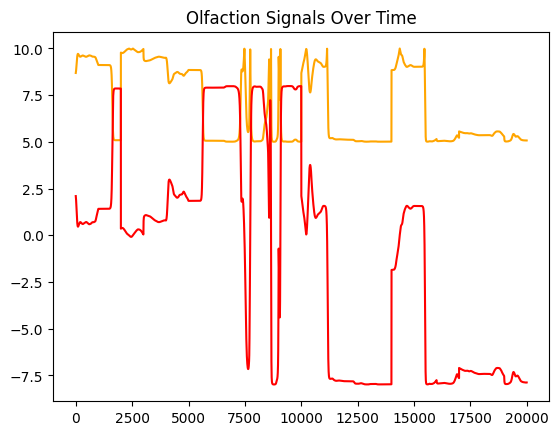

In [4]:
plt.figure()
plt.plot(x, olfactory_signal[:,0], color="orange", label="smell left drive")
plt.plot(x, olfactory_signal[:,1], color="red", label="smell right drive")
plt.title("Olfaction Signals Over Time")
plt.show()

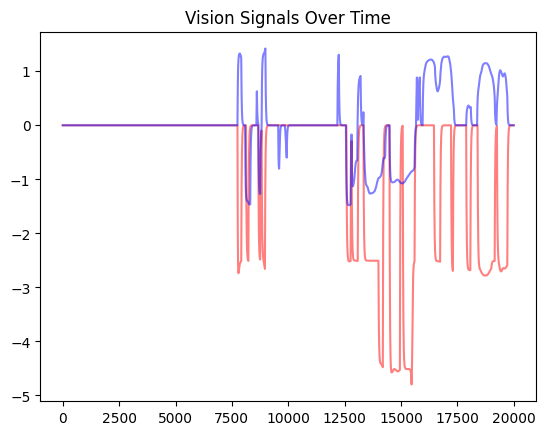

In [5]:
plt.figure()
plt.plot(x, vision_signal[:,0], color="red", label="vision left drive", alpha=0.5)
plt.plot(x, vision_signal[:,1], color="blue", label="vision right drive", alpha=0.5)
#plt.plot(x, np.abs(vision_signal[:,1] - vision_signal[:,0]), color="red", label="vision right drive")
plt.title("Vision Signals Over Time")
plt.show()

In [6]:
controller.olfaction.olfaction_smooth, sim.get_olfaction(sim.fly.name)

(array([[1.25117916e-18],
        [3.03860876e-18],
        [6.09481278e-19],
        [8.50895529e-19]]),
 array([[1.30773329e-18],
        [3.13054796e-18],
        [6.25559340e-19],
        [8.68090655e-19]]))

In [7]:
sim.get_antenna_data(sim.fly.name).keys()

dict_keys(['l', 'r'])

In [8]:
sim.get_antenna_data(sim.fly.name)['l'].keys()

dict_keys(['qpos', 'qvel', 'qacc', 'qfrc_passive'])

In [9]:
sim.get_antenna_data(sim.fly.name)['l']['qvel']

array([-2.56428157, -0.38856703, -0.32777957])

In [10]:
raise KeyboardInterrupt

KeyboardInterrupt: 